# Comparability for 2010-2022 Census Tracts in São Paulo Metropolitan Region (RMSP)

In [1]:
from utils import *

In [2]:
C1 = '2010'
C2 = '2022'
location = 'RMSP'

BASENAME = f'{C1}_{C2}_{location}' # Nome da compatibilização
NAME_C1 = f'{location}_{C1}' # Nome da primeira malha censitária
NAME_C2 = f'{location}_{C2}' # Nome da segunda malha censitária

## 1. Census layers pre-processing
The following cell pre-processes the census layers and only needs to run once

In [3]:
# Importing
layer_2010 = gpd.read_parquet(f'results/{NAME_C1}.parquet')
layer_2022 = gpd.read_parquet(f'results/{NAME_C2}.parquet')

## 2. Comparability graph

In [4]:
G_compat = comparability_graph(layer_2010, layer_2022)

'comparability_graph.makeGridUnion' executed in 133.9004s.
'getNeighborhoods' executed in 0.0565s.
'getNeighborhoods' executed in 0.1101s.
'comparability_graph.classifyGridChanges' executed in 17.7098s.
'comparability_graph.__init__' executed in 156.9832s.


In [5]:
G_compat.findMaintenances()
G_compat.findSplitings(threshold=0.8)

# Aplica séries de buffers
for b in [-20, -10]:
    G_compat.forceOverlay(buffer=b)

# Sobreposição de isolados restantes
G_compat.forceOverlay(buffer=0, use_all=True)

'comparability_graph.findMaintenances' executed in 0.0414s.
'comparability_graph.findSplitings' executed in 1.2221s.
'comparability_graph.forceOverlay' executed in 19.9832s.
'comparability_graph.forceOverlay' executed in 10.8239s.
'comparability_graph.forceOverlay' executed in 11.3555s.


## 3. Assessing gold standard

In [6]:
# Import gold standard relationship file
df_comp_ibge = pd.read_excel('resources/ibge/Historico_formacao_Setores_Censitarios_2010_2022.xlsx')

nodesA = [int(i[2:]) for i in G_compat.nodes() if i.startswith('A')]
nodesB = [int(i[2:]) for i in G_compat.nodes() if i.startswith('B')]
ibge_2010_2022 = df_comp_ibge[['GEOCODIGO_2022_PRELIMINAR','GEOCODIGO_2010']]
ibge_2010_2022 = ibge_2010_2022.query('GEOCODIGO_2022_PRELIMINAR in @nodesB | GEOCODIGO_2010 in @nodesA')

truth_graph = nx.Graph()

# Add existing nodes
truth_graph.add_nodes_from(G_compat.nodes())

# Add gold standard edges
for _, r in ibge_2010_2022.iterrows():
    truth_graph.add_edge(f"A.{r['GEOCODIGO_2010']}", f"B.{r['GEOCODIGO_2022_PRELIMINAR']}")

# Remove exceding nodes
exceeding_nodes = [i for i in truth_graph.nodes() if i not in G_compat.nodes()]
truth_graph.remove_nodes_from(exceeding_nodes)

In [7]:
G_compat.assessEdges(ground_truth_graph=truth_graph)

'comparability_graph.assessEdges' executed in 1.3108s.


## 4. Export results

In [8]:
G_compat.exportCompatFiles(BASENAME, NAME_C1, NAME_C2)
G_compat.reportCompat(file=f'results/{BASENAME}_report')

'comparability_graph.exportCompatFiles' executed in 16.1546s.
'comparability_graph.reportCompat' executed in 0.1095s.


{'params': {'A/P ratio': 0.3,
  'Lmin': [0.8],
  'Buffers': [{'buffer': -20, 'use_all': False},
   {'buffer': -10, 'use_all': False},
   {'buffer': 0, 'use_all': True}]},
 'layers': {'Setores C1': 30815, 'Setores C2': 47184},
 'relationships': {'Total relationships': {'n': 52115, 'pct': 1},
  '': {'n': 1430, 'pct': 0.02743931689532764},
  'Divisão': {'n': 22600, 'pct': 0.4336563369471361},
  'Manutenção': {'n': 18128, 'pct': 0.34784610956538425},
  'Manutenção desassociada': {'n': 6, 'pct': 0.00011513000095941667},
  'Sobreposição (-10m)': {'n': 2271, 'pct': 0.04357670536313921},
  'Sobreposição (-20m)': {'n': 7116, 'pct': 0.13654418113786818},
  'Sobreposição (0m)': {'n': 564, 'pct': 0.010822220090185167}},
 'operations': {'Total redesign operations': {'n': 27990, 'pct': 1},
  '1:1': {'n': 18733, 'pct': 0.669274740978921},
  '1:n': {'n': 7898, 'pct': 0.28217220435869955},
  'm:n': {'n': 1216, 'pct': 0.04344408717399071},
  'n:1': {'n': 143, 'pct': 0.00510896748838871}},
 'metrics': {'

## 5. Parameter refinement test

In [9]:
for r in range(1,21):
    apr = round(0.1*r,2)
    print('\nTESTING A/P RATIO = ', apr)
    G_compat.reset(ap_ratio=apr)
    G_compat.findMaintenances()
    G_compat.findSplitings(threshold=0.8)
    # Aplica séries de buffers
    for b in [-20, -10]:
        G_compat.forceOverlay(buffer=b)
    # Sobreposição de isolados restantes
    G_compat.forceOverlay(buffer=0, use_all=True)

    G_compat.assessEdges(ground_truth_graph=truth_graph)

    G_compat.exportCompatFiles(BASENAME, NAME_C1, NAME_C2, save_files=False)
    G_compat.reportCompat(file=f'results/params/{BASENAME}_apr{str(apr).replace(".",",")}_report')


TESTING A/P RATIO =  0.1
'comparability_graph.reset' executed in 5.5040s.
'comparability_graph.findMaintenances' executed in 0.0419s.
'comparability_graph.findSplitings' executed in 1.1757s.
'comparability_graph.forceOverlay' executed in 20.1521s.
'comparability_graph.forceOverlay' executed in 10.7089s.
'comparability_graph.forceOverlay' executed in 11.3709s.
'comparability_graph.assessEdges' executed in 1.4857s.
'comparability_graph.exportCompatFiles' executed in 13.2032s.
'comparability_graph.reportCompat' executed in 0.1167s.

TESTING A/P RATIO =  0.2
'comparability_graph.reset' executed in 5.3241s.
'comparability_graph.findMaintenances' executed in 0.0506s.
'comparability_graph.findSplitings' executed in 1.2884s.
'comparability_graph.forceOverlay' executed in 19.8513s.
'comparability_graph.forceOverlay' executed in 10.7439s.
'comparability_graph.forceOverlay' executed in 11.1058s.
'comparability_graph.assessEdges' executed in 1.4716s.
'comparability_graph.exportCompatFiles' execut

In [13]:
for r in range(1,11):
    lmin = round(0.1 * r,2)

    print('\nTESTING Lmin = ', lmin)
    G_compat.reset()
    G_compat.findMaintenances()
    G_compat.findSplitings(threshold=lmin)
    # Aplica séries de buffers
    for b in [-20, -10]:
        G_compat.forceOverlay(buffer=b)
    # Sobreposição de isolados restantes
    G_compat.forceOverlay(buffer=0, use_all=True)

    G_compat.assessEdges(ground_truth_graph=truth_graph)

    G_compat.exportCompatFiles(BASENAME, NAME_C1, NAME_C2, save_files=False)
    G_compat.reportCompat(file=f'results/params/{BASENAME}_lmin{str(lmin).replace(".",",")}_report.json')


TESTING Lmin =  0.1
'comparability_graph.reset' executed in 5.7554s.
'comparability_graph.findMaintenances' executed in 0.0465s.
'comparability_graph.findSplitings' executed in 1.5029s.
'comparability_graph.forceOverlay' executed in 13.1056s.
'comparability_graph.forceOverlay' executed in 9.6168s.
'comparability_graph.forceOverlay' executed in 10.9259s.
'comparability_graph.assessEdges' executed in 1.2897s.
'comparability_graph.exportCompatFiles' executed in 13.0248s.
'comparability_graph.reportCompat' executed in 0.1069s.

TESTING Lmin =  0.2
'comparability_graph.reset' executed in 5.2845s.
'comparability_graph.findMaintenances' executed in 0.1866s.
'comparability_graph.findSplitings' executed in 1.3815s.
'comparability_graph.forceOverlay' executed in 13.2928s.
'comparability_graph.forceOverlay' executed in 9.8482s.
'comparability_graph.forceOverlay' executed in 10.7486s.
'comparability_graph.assessEdges' executed in 1.4206s.
'comparability_graph.exportCompatFiles' executed in 12.790

In [14]:
df_apr = readMetrics(BASENAME, 'apr')
df_lmin = readMetrics(BASENAME, 'lmin')

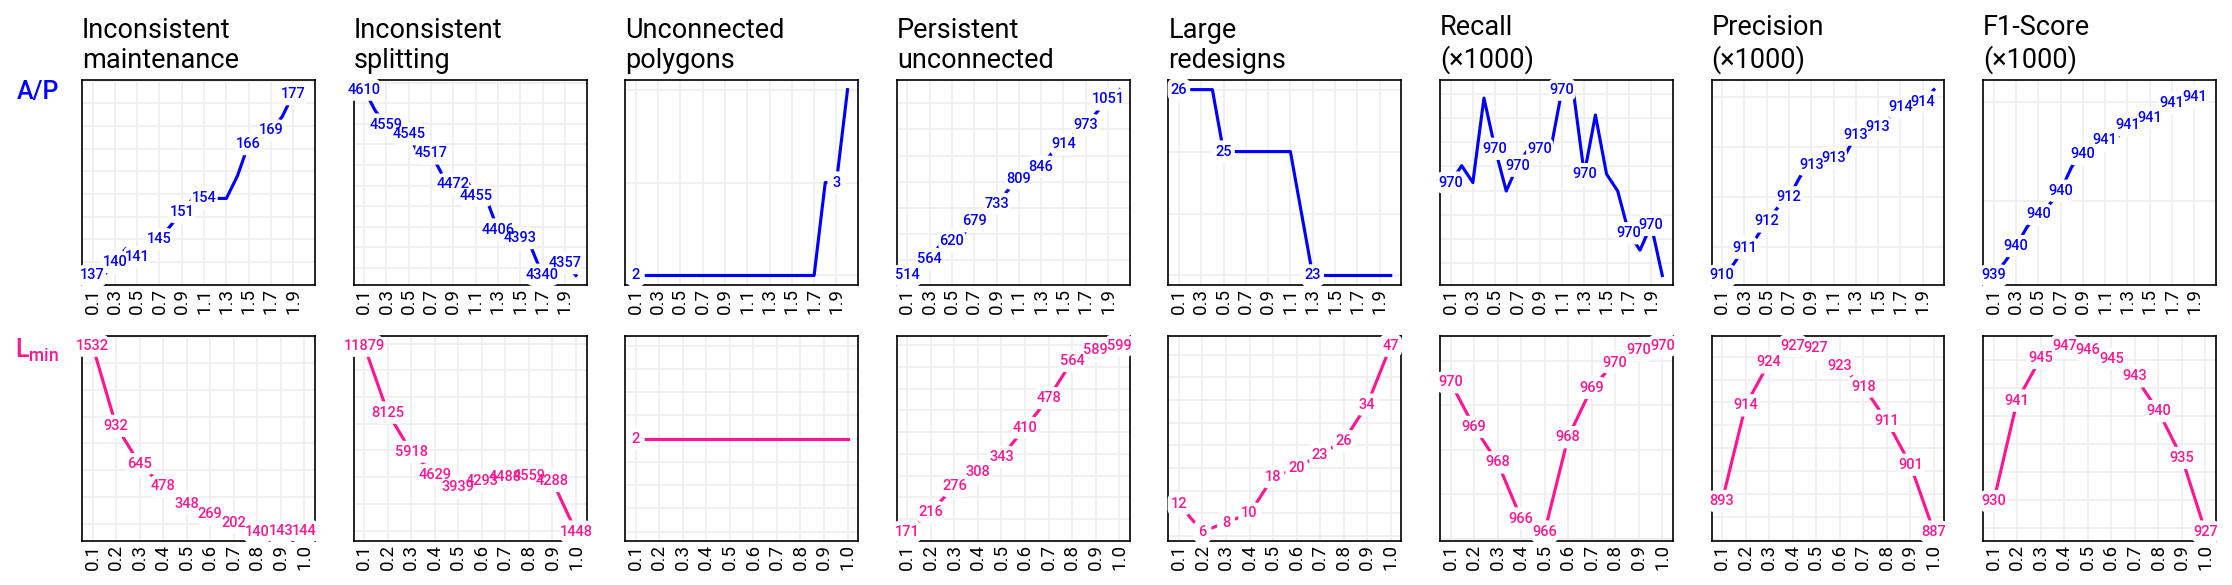

In [24]:
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
params = {'mathtext.default': 'regular' , 'font.family':'Roboto'} 
plt.rcParams.update(params)
import seaborn as sns

labels = {
    'Inconsistent maintenance': 'Inconsistent\nmaintenance',
    'Inconsistent splitting':'Inconsistent\nsplitting',
    'Unconnected polygons':'Unconnected\npolygons',
    'Persistent unconnected':'Persistent\nunconnected',
    'Large redesigns':'Large\nredesigns',
    'recall': 'Recall\n(×1000)',
    'precision': 'Precision\n(×1000)',
    'f1_score': 'F1-Score\n(×1000)'
}

fig, ax = plt.subplots(2,len(df_apr.columns)-1,figsize=(15, 4), dpi=150)

for j, c in enumerate([i for i in df_apr.columns if i != 'A/P ratio']):
    i = (0,j)
    group_df = df_apr[['A/P ratio', c]]
    sns.lineplot(x='A/P ratio',y=c, data=group_df, color='blue', ax=ax[i], marker='None')

    # Anotações
    coords = [(x, y) for x,y in zip(group_df['A/P ratio'], group_df[c])]
    t=None
    for coord in coords[::2]:
        if coord[1]!=t:
            t = ax[i].annotate(f'{round(coord[1],0):n}', fontsize=4, xy=coord, textcoords='data', ha='center', va='center', color='white')
            t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0, boxstyle='round,pad=0.8'))
            t = coord[1]
    t=None
    for coord in coords[::2]:
        if coord[1]!=t:
            ax[i].annotate(f'{round(coord[1],0):n}', fontsize=7, color='blue', xy=coord, textcoords='data', ha='center', va='center',zorder=5, fontweight='medium')
            t = coord[1]

    ax[i].set_title(labels[c], fontsize=13, ha='left', x=0)
    ax[i].xaxis.set_label_text('')

    ax[i].xaxis.set_ticks(group_df['A/P ratio'].to_list()[::2])
    ax[i].tick_params(axis='x', color='white', labelcolor='black', labelsize=9, rotation=90, pad=-2)

    [t.set_color('#aaaaaa') for t in ax[i].yaxis.get_ticklabels()]
    [t.set_va('bottom') for t in ax[i].yaxis.get_ticklabels()]
    ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))
    ax[i].yaxis.set_ticklabels([t for t in ax[i].yaxis.get_ticklabels()])
    #ax[i].xaxis.set_ticklabels([])
    ax[i].yaxis.set_ticklabels([])
    ax[i].yaxis.set_label_text('')
    ax[i].tick_params(axis='y', color='white')

    if j==0:
        ax[i].set_ylabel('A/P', loc='top', va='top', fontsize=12, fontweight='medium')
        #ax[i].yaxis.set_label_text(r'A/P')
        ax[i].yaxis.label.set_color('blue')
        ax[i].yaxis.label.set_rotation(0)

    ax[i].grid(axis='y', visible=True, color='#eeeeee')
    ax[i].grid(axis='x', visible=True, color='#eeeeee')
    ax[i].set_facecolor("white")

for j, c in enumerate([i for i in df_lmin.columns if i != 'Lmin']):
    i = (1,j)
    group_df = df_lmin[['Lmin', c]]
    sns.lineplot(x='Lmin',y=c, data=group_df, color='deeppink', ax=ax[i], marker='None')

    # Anotações
    coords = [(x, y) for x,y in zip(group_df['Lmin'], group_df[c])]
    t=None
    for coord in coords:
        if coord[1]!=t:
            t = ax[i].annotate(f'{round(coord[1],0):n}', fontsize=4, xy=coord, textcoords='data', ha='center', va='center', color='white')
            t.set_bbox(dict(facecolor='white', alpha=1, linewidth=0, boxstyle='round,pad=0.8'))
            t = coord[1]
    t=None
    for coord in coords:
        if coord[1]!=t:
            ax[i].annotate(f'{round(coord[1],0):n}', fontsize=7, color='deeppink', xy=coord, textcoords='data', ha='center', va='center',zorder=5, fontweight='medium')
            t = coord[1]

    #ax[i].set_title(c.replace(' ','\n').replace('nao\npuras','nao puras'), ha='left', x=0)
    ax[i].xaxis.set_label_text('')

    ax[i].xaxis.set_ticks(group_df['Lmin'].to_list())
    ax[i].tick_params(axis='x', color='white', labelcolor='black', labelsize=9, rotation=90, pad=-2)

    [t.set_color('#aaaaaa') for t in ax[i].yaxis.get_ticklabels()]
    [t.set_va('bottom') for t in ax[i].yaxis.get_ticklabels()]
    ax[i].yaxis.set_major_locator(MaxNLocator(integer=True))
    ax[i].yaxis.set_ticklabels([t for t in ax[i].yaxis.get_ticklabels()])
    #ax[i].xaxis.set_ticklabels([])
    ax[i].yaxis.set_ticklabels([])
    ax[i].yaxis.set_label_text('')
    ax[i].tick_params(axis='y', color='white')

    if j==0:
        ax[i].set_ylabel('$L_{min}$', loc='top', va='top', fontsize=12, fontweight='medium')
        #ax[i].yaxis.set_label_text('$L_{min}$')
        ax[i].yaxis.label.set_color('deeppink')
        ax[i].yaxis.label.set_rotation(0)

    ax[i].grid(axis='y', visible=True, color='#eeeeee')
    ax[i].grid(axis='x', visible=True, color='#eeeeee')
    ax[i].set_facecolor("white")

fig.tight_layout()
plt.savefig(f'docs/analise_params_{location}.png', bbox_inches='tight')
plt.show()

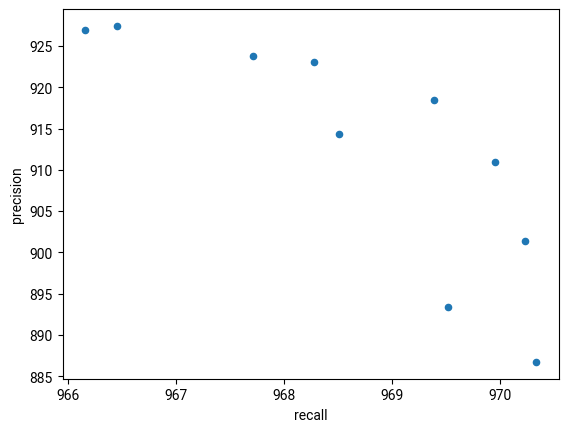

In [25]:
df_lmin.plot.scatter(x='recall', y='precision')
plt.savefig(f'docs/f1-score_lmin_{location}.png', bbox_inches='tight')

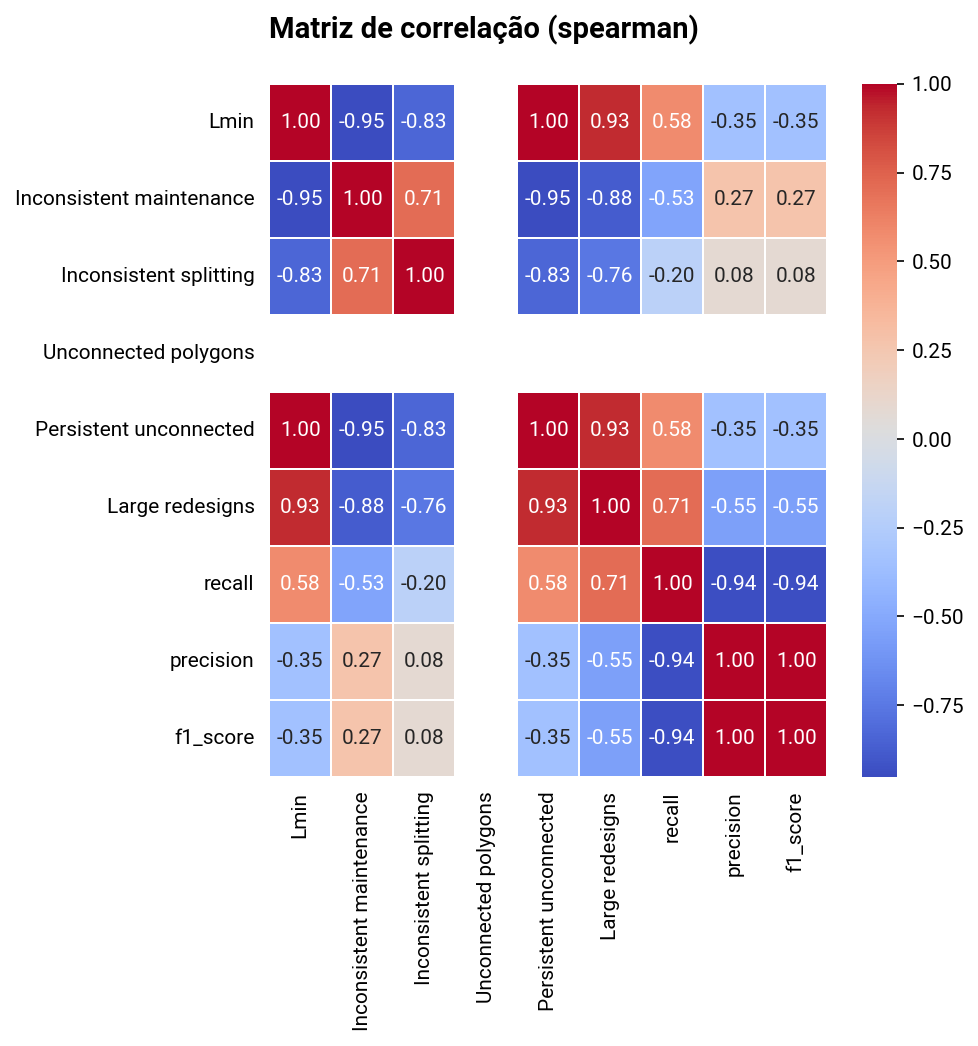

In [26]:
fig, ax = plt.subplots(1,1,figsize=(6, 6), dpi=150) # Adjust figure size as needed
sns.heatmap(df_lmin.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", ax=ax, linewidth=.1, robust=True)
ax.set_title('Matriz de correlação (spearman)\n', fontsize=14, ha='left', x=0, weight='bold')
ax.tick_params(axis='y', color='white')
ax.tick_params(axis='x', color='white')
plt.savefig(f'docs/corr-spearman_lmin_{location}.png', bbox_inches='tight')
plt.show()

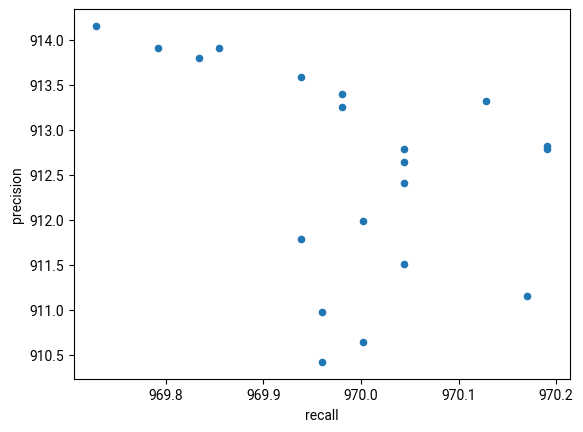

In [27]:
df_apr.plot.scatter(x='recall', y='precision')
plt.savefig(f'docs/f1-score_apr_{location}.png', bbox_inches='tight')

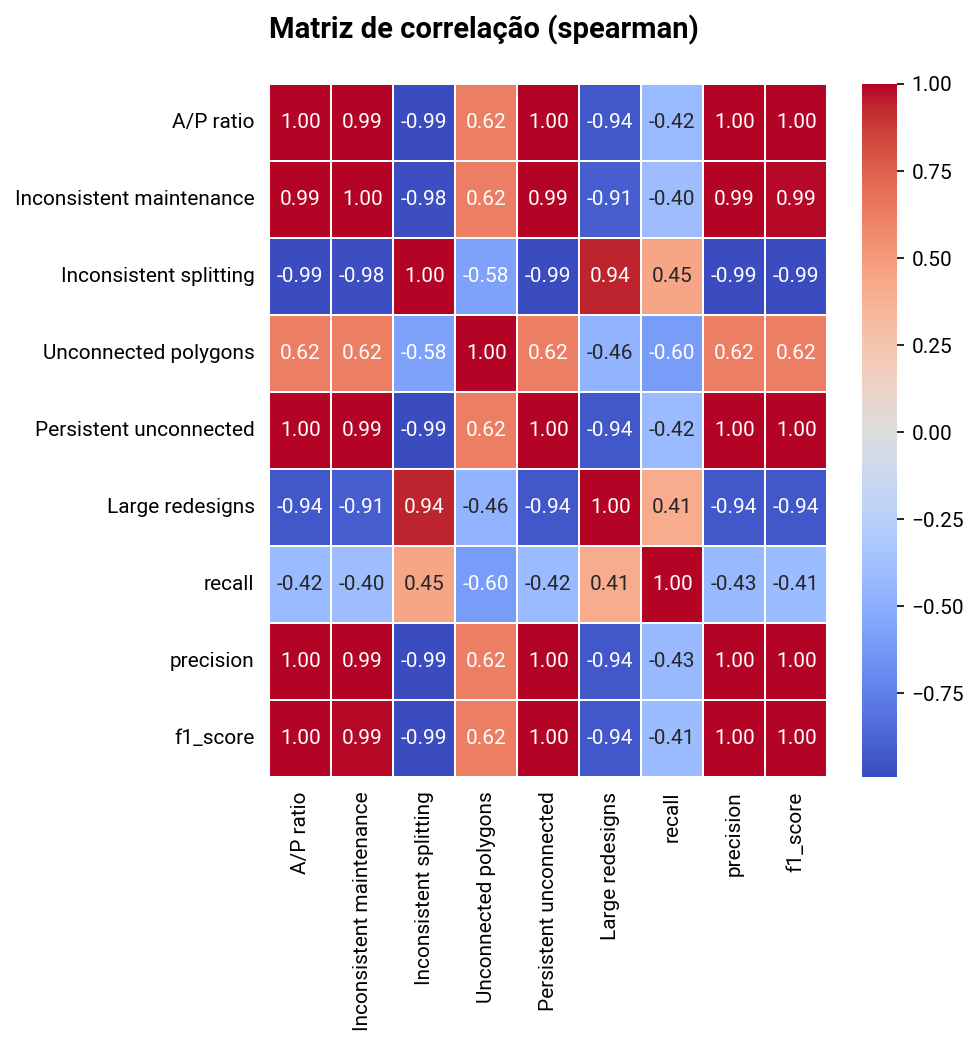

In [28]:
fig, ax = plt.subplots(1,1,figsize=(6, 6), dpi=150) # Adjust figure size as needed
sns.heatmap(df_apr.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", ax=ax, linewidth=.1, robust=True)
ax.set_title('Matriz de correlação (spearman)\n', fontsize=14, ha='left', x=0, weight='bold')
ax.tick_params(axis='y', color='white')
ax.tick_params(axis='x', color='white')
plt.savefig(f'docs/corr-spearman_apr_{location}.png', bbox_inches='tight')
plt.show()